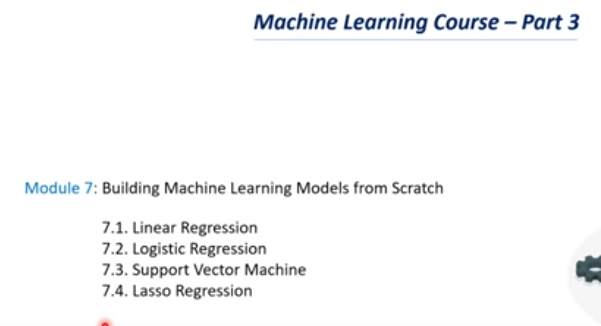

## Linear Regression - Intuition

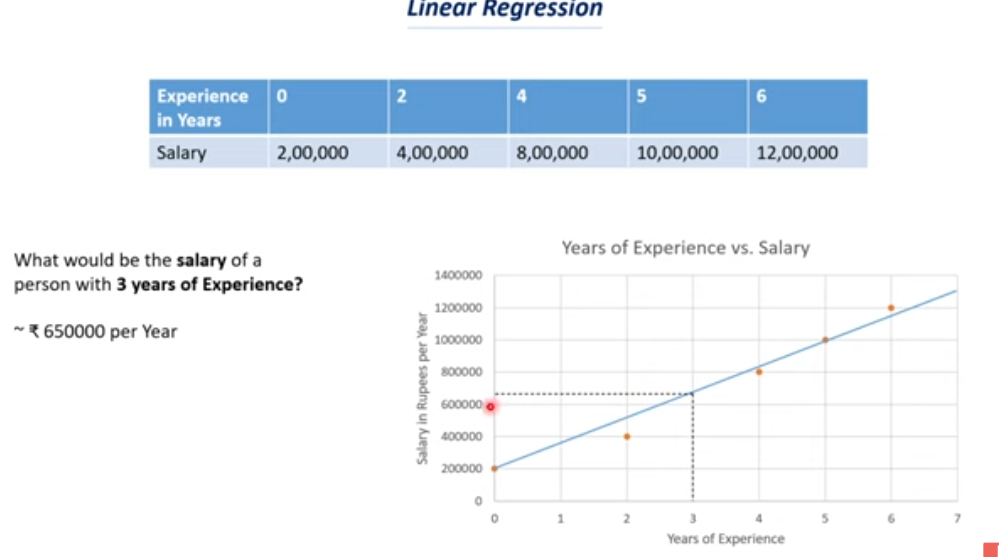

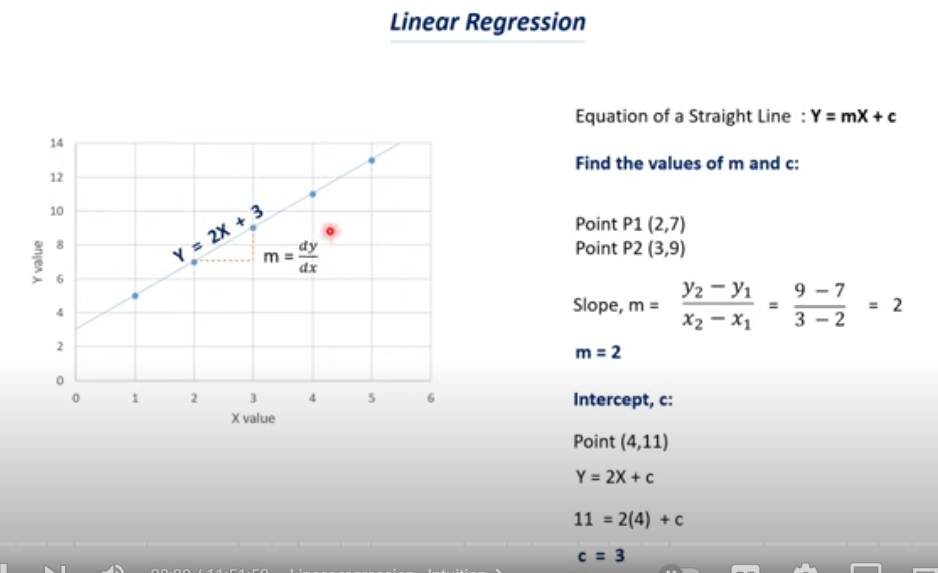

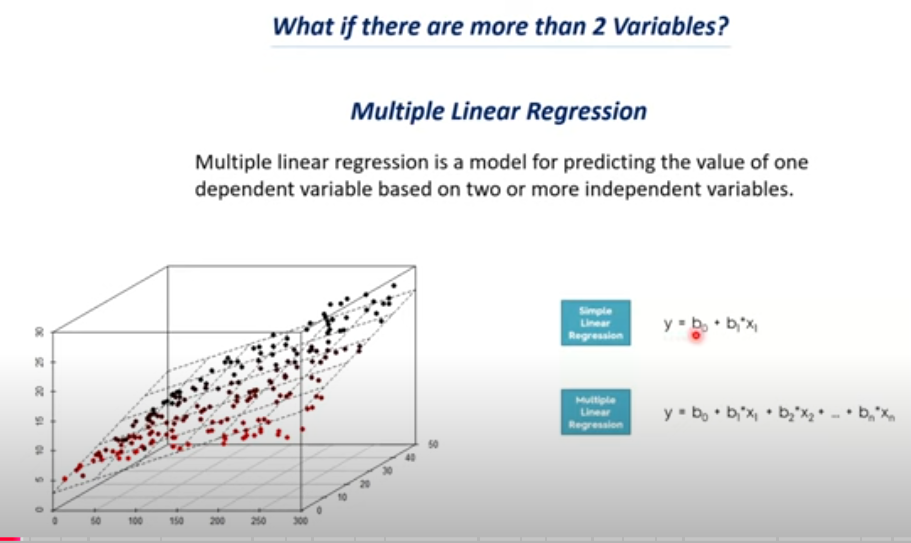

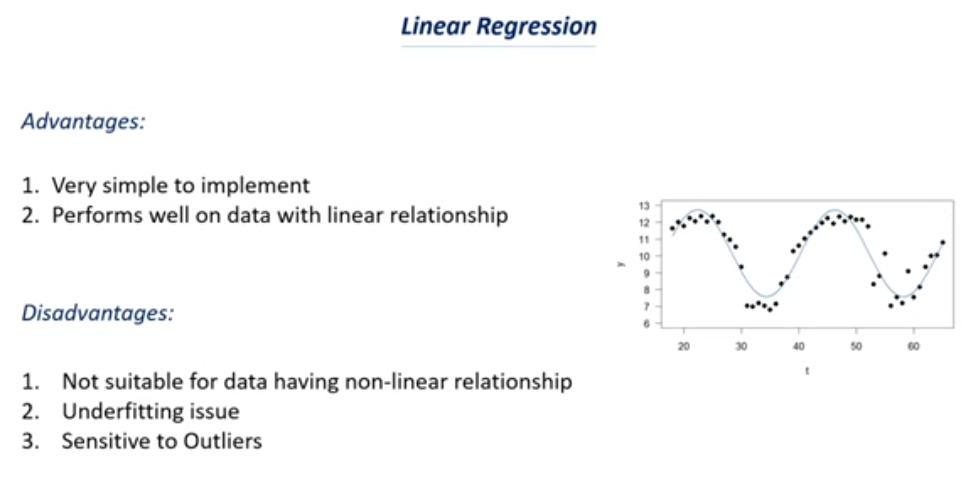

## 32.33 Linear Regression - Mathematical Understanding

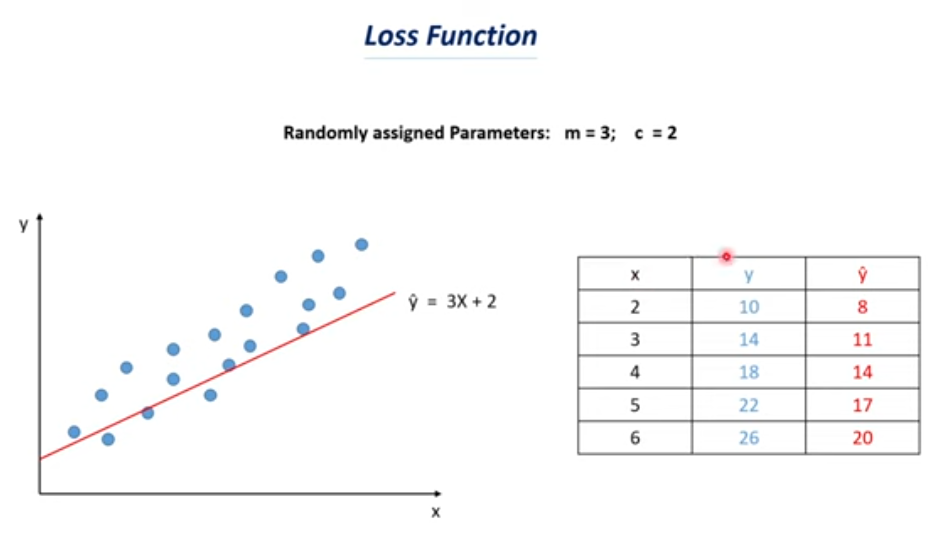

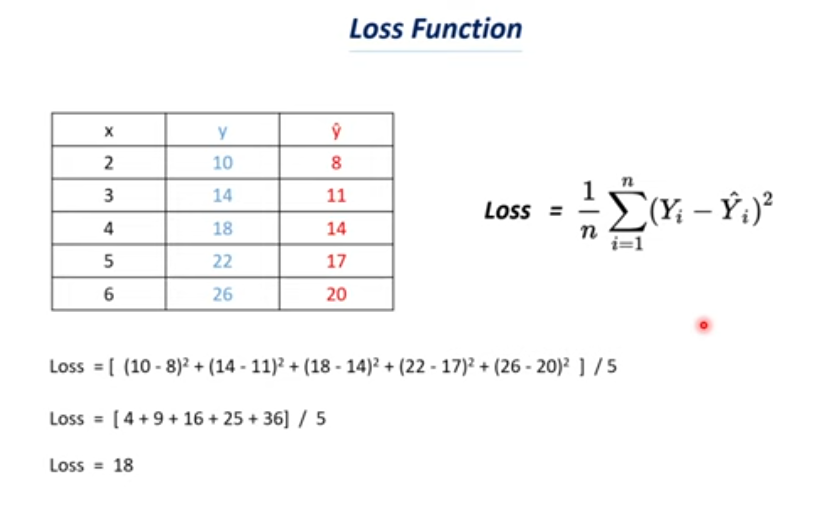

Loss is high --> low accuracy

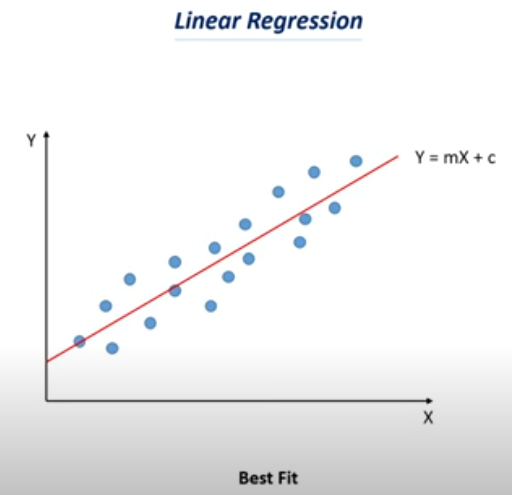

### 52.27 - Gradient Descent for Linear Regression

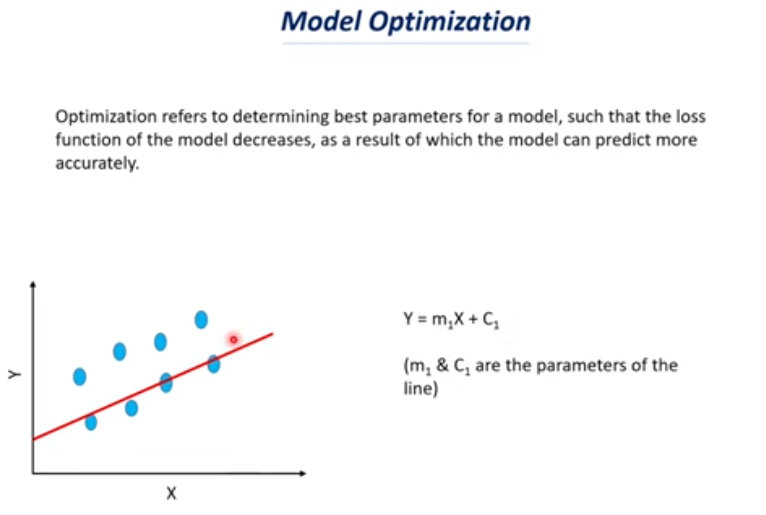

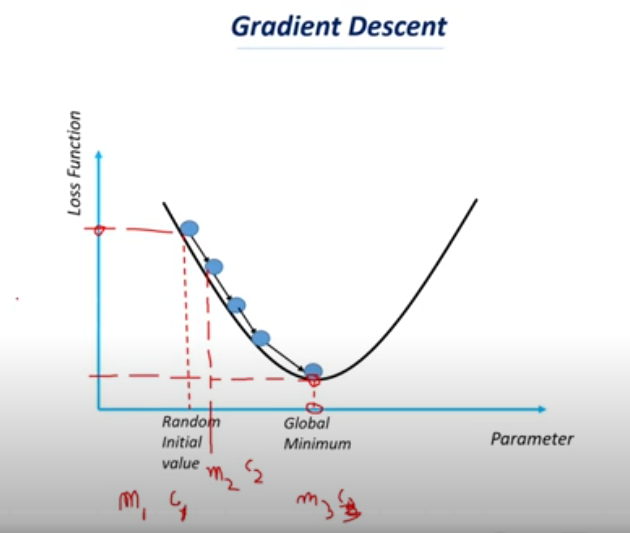

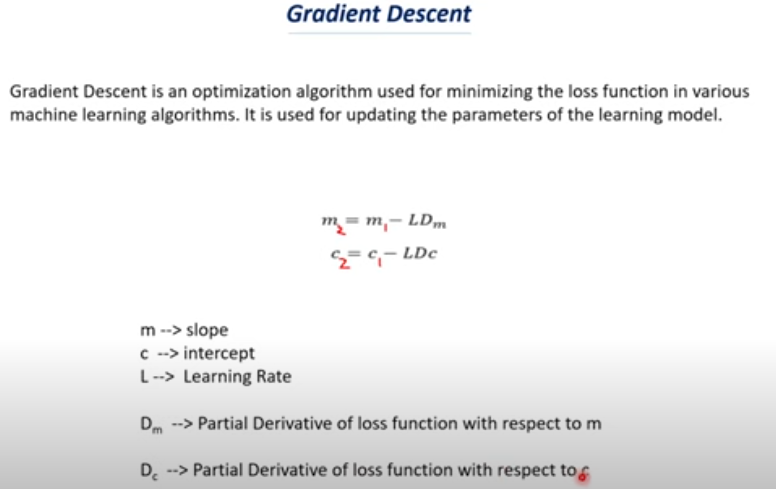

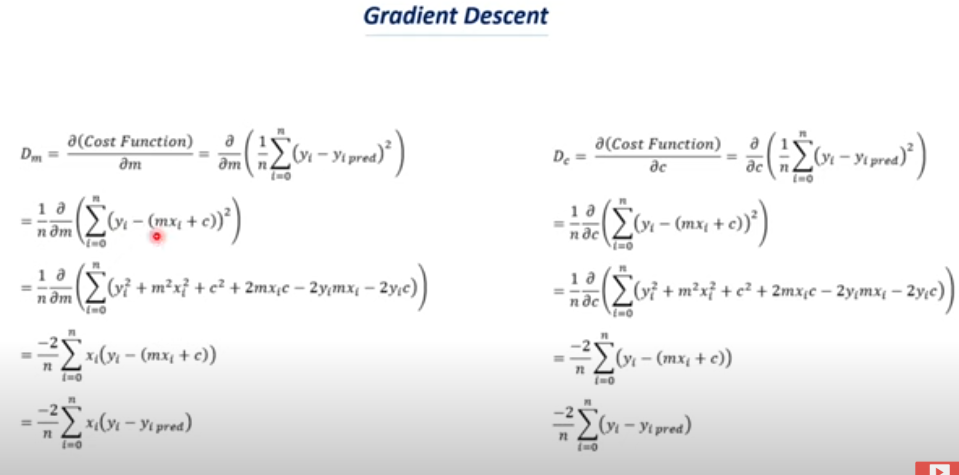

## Building a linear regression model

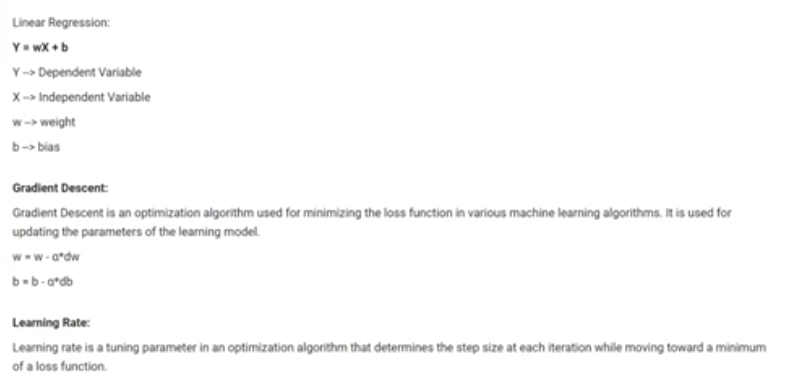

In [6]:
import pandas as pd
data = pd.read_csv('D:/Education/_Machine Learning/experience_salary_data.csv')

In [8]:
data.head()

,Years of Experience,Salary
0,8.116262,50223.169522
1,19.063572,72370.374910
2,14.907885,71382.436797
3,12.374511,54832.059750
4,3.964354,40955.203396


In [10]:
import numpy as np

In [12]:
x = data['Years of Experience']
y = data['Salary']

In [14]:
# Linear regression model
class LinearRegression:
    #initating parameters
    def __init__(self,learning_rate, no_of_iteration):
        self.learning_rate = learning_rate
        self.no_of_iteration = no_of_iteration
    # 
    def fit(self, x, y):
        # number of training example and nu of features
        self.m, self.n = x.shape # no of rows and cols
        # initating weight and bias of model
        self.w = np.zeros(self.n)
        self.b = 0 # if features more more weight values are there but model has 1 bias
        self.x = x
        self.y = y

        #impletemnt gradient descent
        for i in range(self.no_of_iteration):
            self.update_weights()
        
    def update_weights(self):
        y_prediction = self.predict(self.x)
        #calculate gradient
        dw = -(2 * (self.x.T).dot(self.y - y_prediction)) / self.m
        db = -2 * np.sum(self.y - y_prediction)/self.m

        #updating weights
        self.w = self.w - self.learning_rate*dw
        self.b = self.b - self.learning_rate*db
        
    def predict(self,x):
        return x.dot(self.w) + self.b
        
    

## * why two values for fit function --> 1.47.59

## --> implementing model 2.00.33

### using lin.regression model for prediction

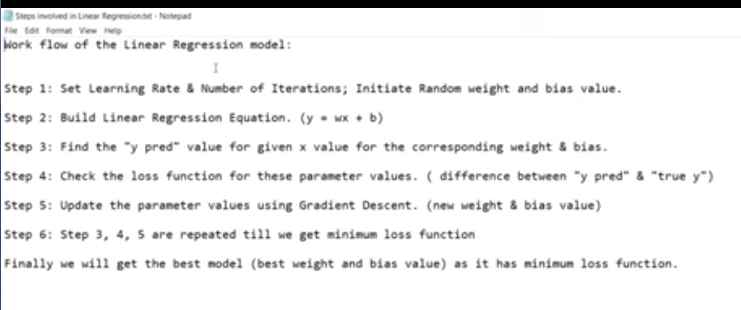

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [23]:
x.shape, y.shape

((40,), (40,))

In [25]:
data.head()

,Years of Experience,Salary
0,8.116262,50223.169522
1,19.063572,72370.374910
2,14.907885,71382.436797
3,12.374511,54832.059750
4,3.964354,40955.203396


In [27]:
data.shape

(40, 2)

In [31]:
# checking for missing values
data.isnull().sum()

Years of Experience    0
Salary                 0
dtype: int64

In [43]:
X = data.iloc[:,:-1].values # all rows and column other than last
Y = data.iloc[:,1].values # first column

In [45]:
X.shape, x.shape

((40, 1), (40,))

In [52]:
Y.shape

(40,)

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size = 0.1)

In [114]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [116]:
y_test.shape

(4,)

### Training model

In [119]:
model = LinearRegression(learning_rate=0.02, no_of_iteration=100)

In [121]:
model.fit(X_train, y_train)

In [123]:
pred = model.predict(X_train)
from sklearn.metrics import accuracy_score

In [125]:
print('weight', model.w[0])
print('biast',model.b)

weight 13888.898389889666
biast 53377.142481512135


equation look like , y = (-1.2199342301523204e+68)*x+(-9.197525728122187e+66)

In [128]:
test_pred = model.predict(X_test)

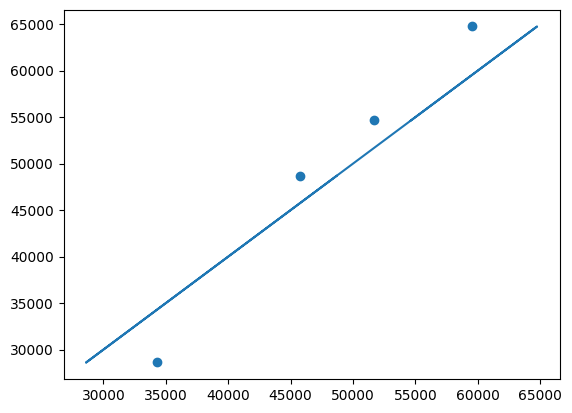

In [144]:

plt.scatter(test_pred, y_test)
plt.plot(y_test,y_test)

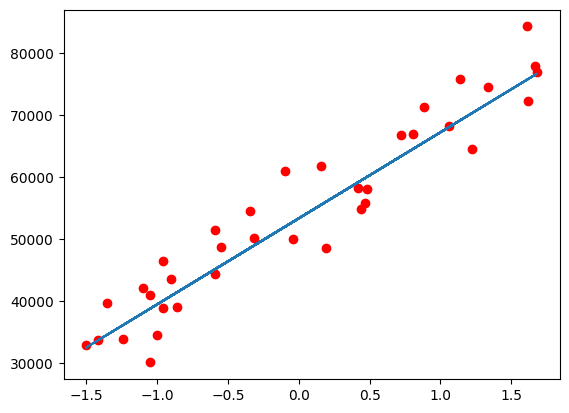

In [156]:
plt.plot(X_train, pred)
plt.scatter(X_train,y_train,c='red')


### Logistic regression 3.04.21

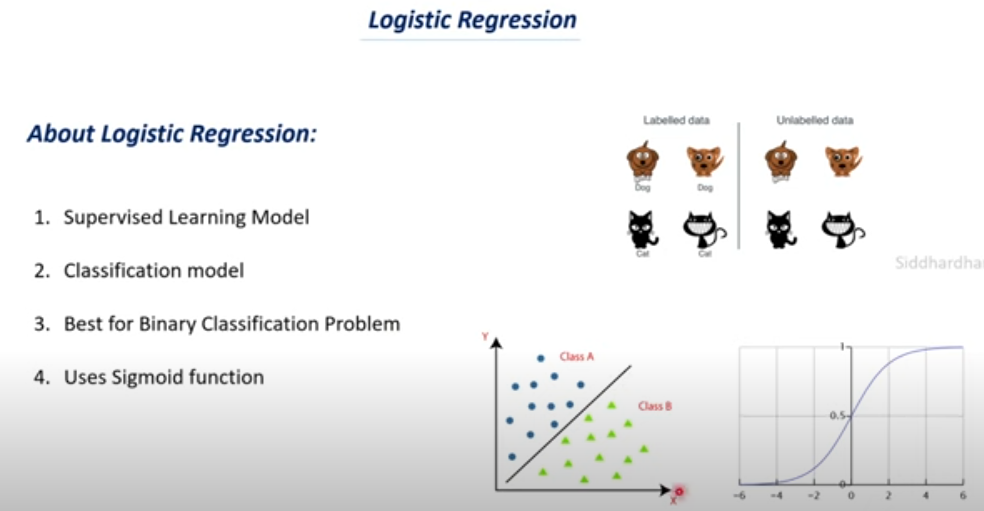

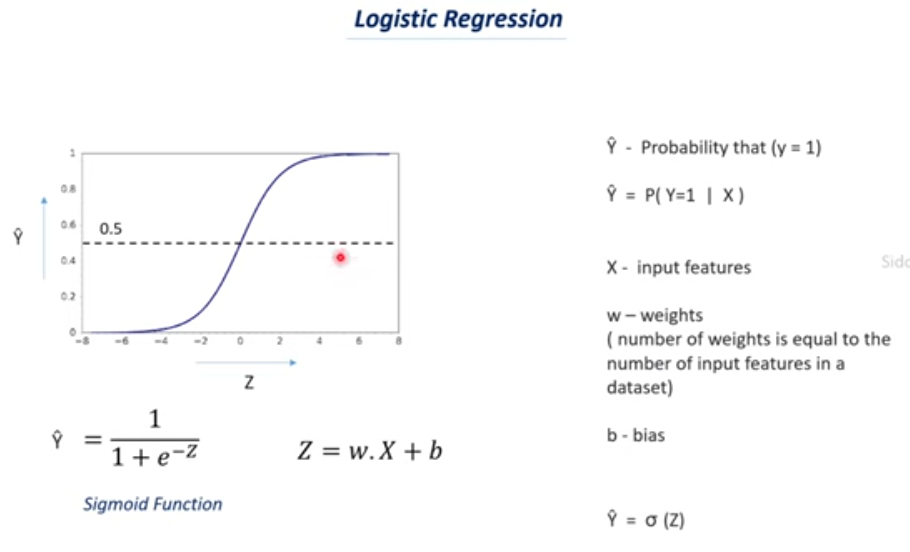

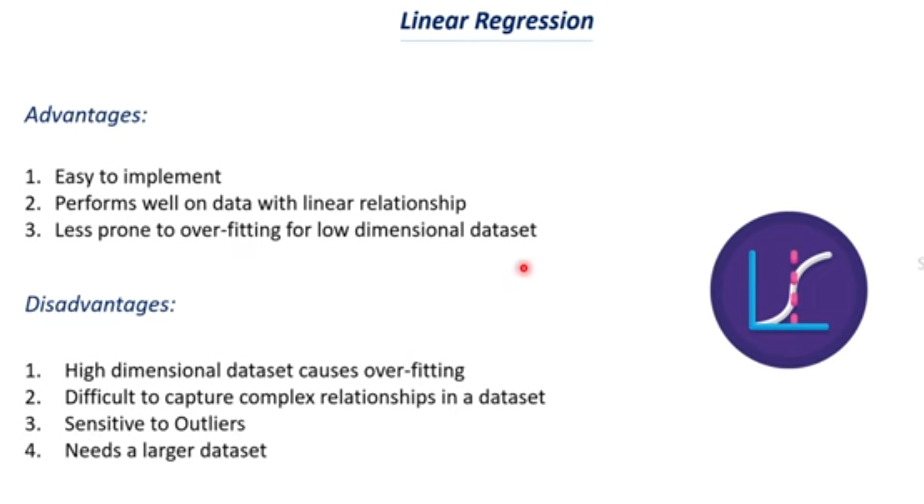

### 3.43.53 - Loss funtion and cost function for logistic regression

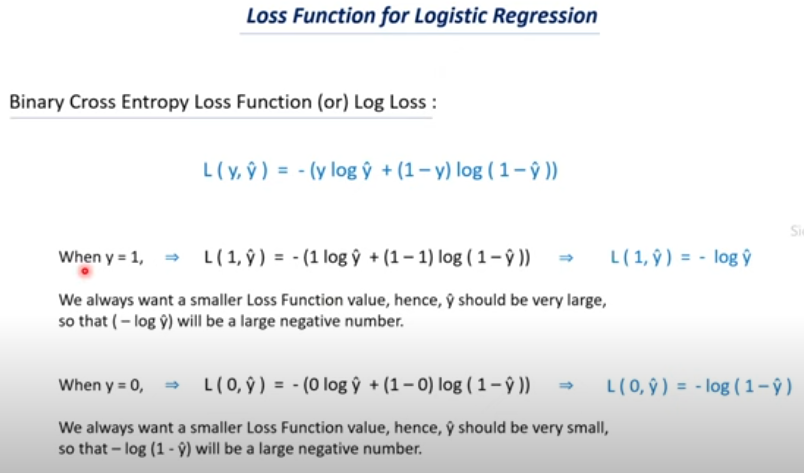

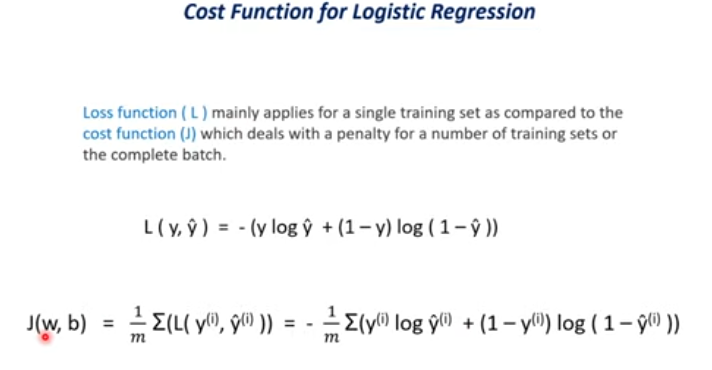

### 4.12.58 - Gradient Descent for Logistic regression

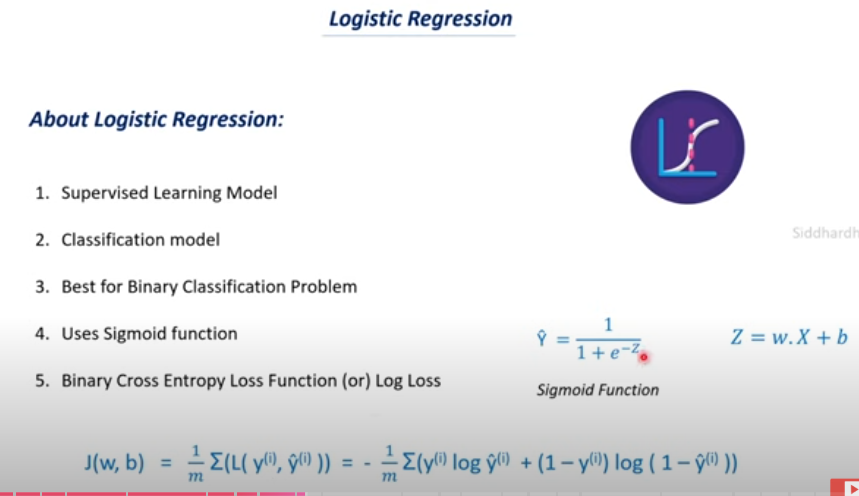

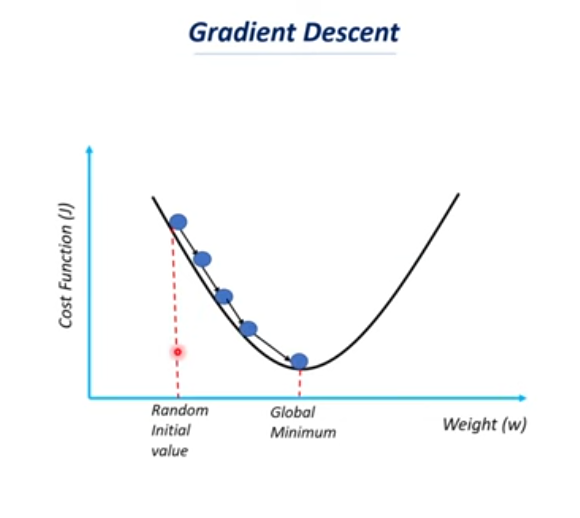

 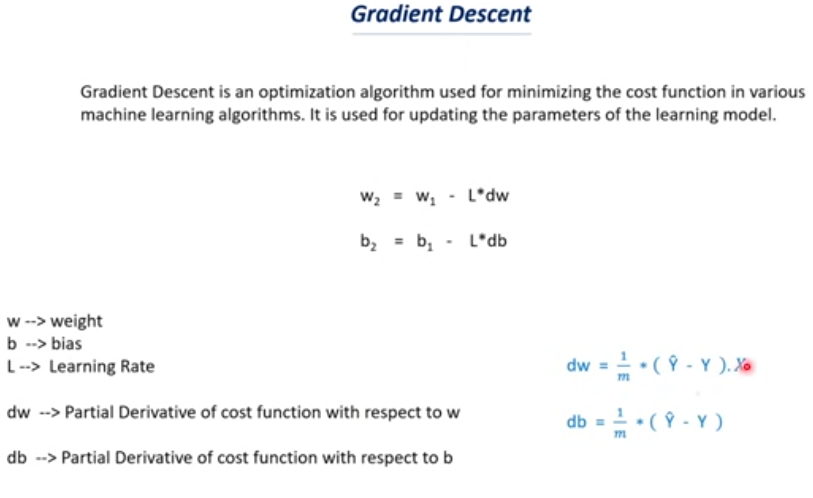

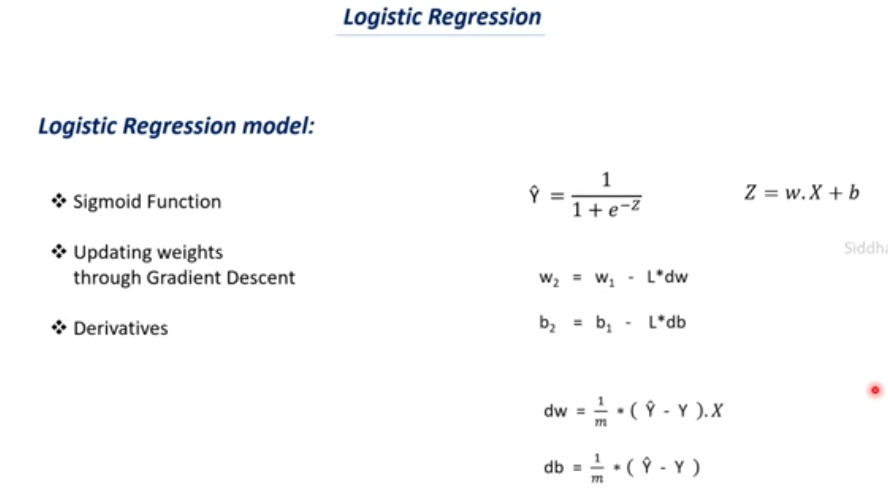

## building Logistic regression 4.40

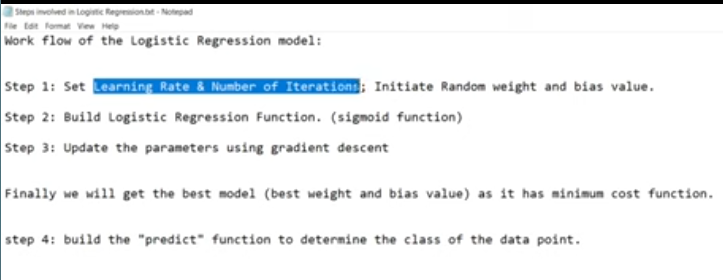

In [1]:
import numpy as np

In [50]:
class Logistic_regression():
    #initiating parameters
    def __init__(self, learning_rate, no_of_iterations):
        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations

    def fit(self, x,y):
        self.m, self.n = x.shape # no of samples and inpute features

        #initiating weight and baias value
        self.w = np.zeros(self.n)
        self.b = 0
        self.x = x
        self.y = y

        # implemnting gradient descent
        for i in range(self.no_of_iterations):
            self.update_weights()
        

    def update_weights(self):
        # y_hat formuala (sigmoid)
        y_hat = 1/(1+np.exp(-(self.x.dot(self.w)+self.b))) 

        #derivatives
        dw = (1/self.m)*np.dot(self.x.T, (y_hat - self.y))
        db = (1/self.m)*np.sum(y_hat - self.y)

        # updating w and b
        self.w = self.w - self.learning_rate * dw
        self.b -= self.learning_rate * db

        

    def predict(self, x):
        y_pred = 1/(1+np.exp(-(self.x.dot(self.w)+self.b)))
        y_pred = np.where(y_pred > 0.5, 1, 0) # we make only 0 or 1 output
        return y_pred
        

### 5.37.44 - applying the model

In [4]:
import pandas as pd

In [5]:
data = pd.read_csv('D:/Education/_Machine Learning/diabetes.csv')

In [16]:
from sklearn.preprocessing import StandardScaler

In [46]:
x = [1,2,3,4,5,6]
b = []
for i in range(len(x)):
    y = np.where(x[i]>3,1,0)
    b.append(y)

In [48]:
b

[array(0), array(0), array(0), array(1), array(1), array(1)]

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [54]:
data.shape

(768, 9)

In [56]:
data.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [58]:
features = data.drop(columns='Outcome', axis=1)
target = data['Outcome']

In [62]:
features.std()

Pregnancies                   3.369578
Glucose                      31.972618
BloodPressure                19.355807
SkinThickness                15.952218
Insulin                     115.244002
BMI                           7.884160
DiabetesPedigreeFunction      0.331329
Age                          11.760232
dtype: float64

In [66]:
scaler = StandardScaler()
scaler.fit(features)

StandardScaler()

In [68]:
std_data = scaler.transform(features)

In [74]:
std_data.shape

(768, 8)

In [76]:
features = std_data
target = data['Outcome']

In [78]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.1, random_state=42)

In [80]:
len(X_train), len(X_test)

(691, 77)